# SIDE24 public coefficient viewer

**NON-CERTIFYING visualization of already published numbers.** This notebook displays the published coefficient intervals for dimensions 2 and 3. It does not prove a theorem, perform a new enclosure, simulate a random field, or evaluate a lifetime law.

The exact input is [`coefficients/side24_v1/ENCLOSURE.json`](https://github.com/d6g8k5htny-coder/Math-/blob/9d7b6802424fb4715b31999066aafca8ee2f3cca/coefficients/side24_v1/ENCLOSURE.json) from public `Math-` commit `9d7b6802424fb4715b31999066aafca8ee2f3cca`: **1090 bytes**, SHA256 `72b6cd92d31394cdaf5da8919a5d548e902228af1f095cc184158a71d8287811`.

Read the [pinned coefficient proof and scope](https://github.com/d6g8k5htny-coder/Math-/blob/9d7b6802424fb4715b31999066aafca8ee2f3cca/coefficients/side24_v1/PROOF.md). The retained source says `scientific_acceptance: false` and describes its parent theorem as unreviewed; this notebook preserves those original fields. Later [scoped coefficient review](https://github.com/d6g8k5htny-coder/main/issues/65#issuecomment-5841269490) and [current program status](https://github.com/d6g8k5htny-coder/main/blob/main/STATUS.md) are separate records. Their links do not promote the parent theorem or change this source.

Run the cells in order. Fetching and identity checks use only Python's standard library. Matplotlib, if already installed (as in Colab), draws the optional chart; no package installation is required for the exact table.

The committed preview was executed locally from the exact verified bytes in the public Git checkout, supplied at the fetch boundary. Re-running the fetch cell retrieves and verifies the pinned public URL directly.


In [1]:
import hashlib
import json
import urllib.request
from decimal import Decimal, localcontext

SOURCE_COMMIT = "9d7b6802424fb4715b31999066aafca8ee2f3cca"
SOURCE_PATH = "coefficients/side24_v1/ENCLOSURE.json"
SOURCE_URL = (
    "https://raw.githubusercontent.com/d6g8k5htny-coder/Math-/"
    + SOURCE_COMMIT + "/" + SOURCE_PATH
)
EXPECTED_BYTES = 1090
EXPECTED_SHA256 = "72b6cd92d31394cdaf5da8919a5d548e902228af1f095cc184158a71d8287811"


def decode_verified_source(raw):
    # Check raw bytes before JSON decoding or plotting. Never fall back to a mutable ref.
    if len(raw) != EXPECTED_BYTES:
        raise ValueError("Source byte count mismatch; refusing to display this input")
    if hashlib.sha256(raw).hexdigest() != EXPECTED_SHA256:
        raise ValueError("Source SHA256 mismatch; refusing to display this input")
    source = json.loads(raw.decode("utf-8"))
    if source.get("scientific_acceptance") is not False:
        raise ValueError("Unexpected source acceptance field")
    return source


with urllib.request.urlopen(SOURCE_URL, timeout=30) as response:
    raw_source = response.read(EXPECTED_BYTES + 1)
source = decode_verified_source(raw_source)
print("Verified:", SOURCE_COMMIT, SOURCE_PATH)
print("Bytes:", len(raw_source), "SHA256:", hashlib.sha256(raw_source).hexdigest())
print("Original scientific_acceptance:", source["scientific_acceptance"])
print("Original scope:", source["scope"])


Verified: 9d7b6802424fb4715b31999066aafca8ee2f3cca coefficients/side24_v1/ENCLOSURE.json
Bytes: 1090 SHA256: 72b6cd92d31394cdaf5da8919a5d548e902228af1f095cc184158a71d8287811
Original scientific_acceptance: False
Original scope: coefficient of issue63 Eq15.2; parent theorem unreviewed


In [2]:
# Keep the published endpoint strings intact; Decimal arithmetic is used only
# to choose a midpoint for display. No float is used to validate an interval.
if set(source["dimensions"]) != {"2", "3"}:
    raise ValueError("Unexpected dimension set")
rows = []
with localcontext() as context:
    context.prec = 50
    for dimension in ("2", "3"):
        record = source["dimensions"][dimension]
        lower_text, upper_text = record["lower"], record["upper"]
        if not isinstance(lower_text, str) or not isinstance(upper_text, str):
            raise ValueError("Published decimal endpoints must remain strings")
        lower, upper = Decimal(lower_text), Decimal(upper_text)
        if not lower.is_finite() or not upper.is_finite() or not Decimal(0) < lower < upper:
            raise ValueError("Invalid published interval")
        rows.append({
            "dimension": dimension,
            "lower": lower_text,
            "upper": upper_text,
            "display_midpoint": (lower + upper) / Decimal(2),
        })

print("Exact published endpoints (open intervals):")
for row in rows:
    print("d=" + row["dimension"] + ": " + row["lower"] + " < c < " + row["upper"])
print("Published relative_periodization_bound:", source["relative_periodization_bound"])
print("NON-CERTIFYING display; original scientific_acceptance remains", source["scientific_acceptance"])


Exact published endpoints (open intervals):
d=2: 0.07340691930603427103 < c < 0.07340691930603427104
d=3: 0.04177593184059834334 < c < 0.04177593184059834335
Published relative_periodization_bound: 1e-106
NON-CERTIFYING display; original scientific_acceptance remains False


## Optional approximate chart

Bar heights are floating-point conversions of the decimal midpoints. The published interval widths are about `1e-20`, far below this chart's resolution, so the bars do **not** show enclosure precision or an error probability. Use the exact endpoint strings above for the original intervals. The chart creates no new coefficient, constant, theorem, or scientific verdict.


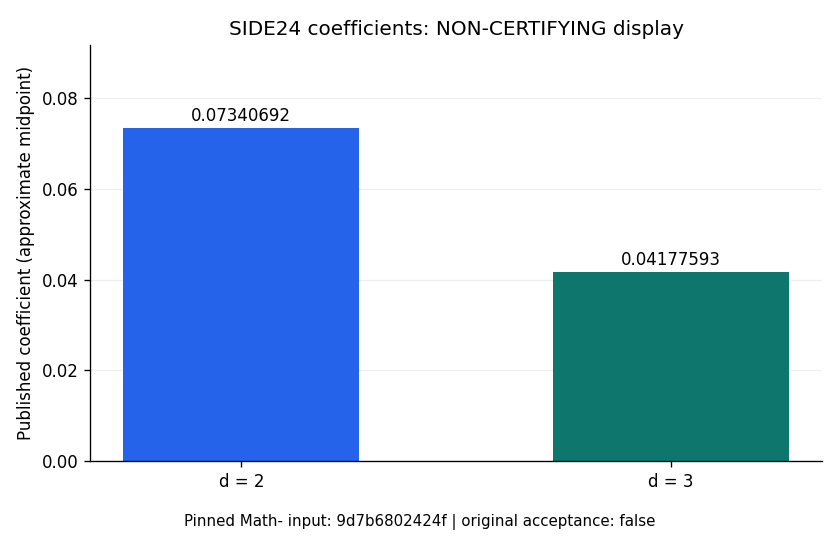

In [3]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib is unavailable. The verified exact table above is complete.")
else:
    dimensions = ["d = " + row["dimension"] for row in rows]
    approximate_midpoints = [float(row["display_midpoint"]) for row in rows]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(dimensions, approximate_midpoints, color=["#2563eb", "#0f766e"], width=0.55)
    ax.set_ylim(0, max(approximate_midpoints) * 1.25)
    ax.set_ylabel("Published coefficient (approximate midpoint)")
    ax.set_title("SIDE24 coefficients: NON-CERTIFYING display")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
    for bar, value in zip(bars, approximate_midpoints):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.0015,
                format(value, ".8f"), ha="center")
    fig.text(0.5, 0.025, "Pinned Math- input: " + SOURCE_COMMIT[:12] + " | original acceptance: false",
             ha="center", fontsize=9)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    plt.show()


## Reproduction and contribution boundary

The fetch cell refuses missing, changed, oversized, or differently hashed input. It never substitutes current `main`, another JSON file, or generated samples. Retain the pinned URL and expected digest when sharing the notebook.

Submit new results through the [public contribution process](https://github.com/d6g8k5htny-coder/main/blob/main/CONTRIBUTING.md). A chart or successful run is review material, not permission to edit `STATUS.md`, `PROOF_INDEX.md`, `claims/`, or `lemma_closed`.
